Model device: cpu
Input device: cpu


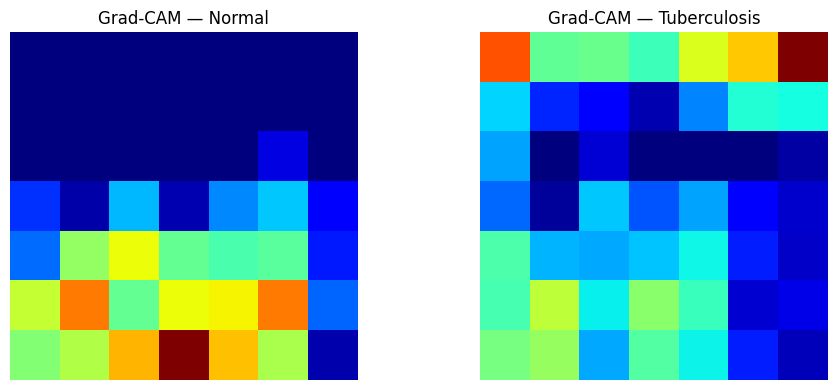

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T
import importlib
import src.explainability.grad_cam
importlib.reload(src.explainability.grad_cam)

from src.models.densenet import build_densenet121
from src.explainability.grad_cam import GradCAM

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_PATH = PROJECT_ROOT / "models" / "transfer" / "densenet121_finetuned.pth"

model = build_densenet121(pretrained=False, freeze_backbone=False)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

target_layer = model.features.denseblock4
gradcam = GradCAM(model, target_layer)

DATA_DIR = PROJECT_ROOT / "data" / "processed"
normal_img_path = next((DATA_DIR / "normal").iterdir())
tb_img_path = next((DATA_DIR / "tuberculosis").iterdir())

RESULTS_DIR = PROJECT_ROOT / "data" / "notebooks" / "results" / "gradcam"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


transform = T.Compose([
    T.Grayscale(num_output_channels=1),
    T.Resize((224, 224)),
    T.ToTensor()
])

def load_image(path):
    img = Image.open(path).convert("L")
    img = transform(img).unsqueeze(0)
    return img.to(DEVICE)

normal_tensor = load_image(normal_img_path)
tb_tensor = load_image(tb_img_path)

# Sanity check
print("Model device:", next(model.parameters()).device)
print("Input device:", normal_tensor.device)

# Generate CAMs
cam_normal = gradcam.generate(normal_tensor)
cam_tb = gradcam.generate(tb_tensor)

fig, axes = plt.subplots(1, 2, figsize = (10, 4))

axes[0].imshow(cam_normal, cmap="jet")
axes[0].set_title("Grad-CAM — Normal")
axes[0].axis("off")

axes[1].imshow(cam_tb, cmap="jet")
axes[1].set_title("Grad-CAM — Tuberculosis")
axes[1].axis("off")

plt.imsave(
    RESULTS_DIR / "normal_gradcam.png",
    cam_normal,
    cmap="jet"
)

plt.imsave(
    RESULTS_DIR / "tuberculosis_gradcam.png",
    cam_tb,
    cmap="jet"
)

plt.tight_layout()

fig.savefig(
    RESULTS_DIR / "gradcam_comparison.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

plt.show()


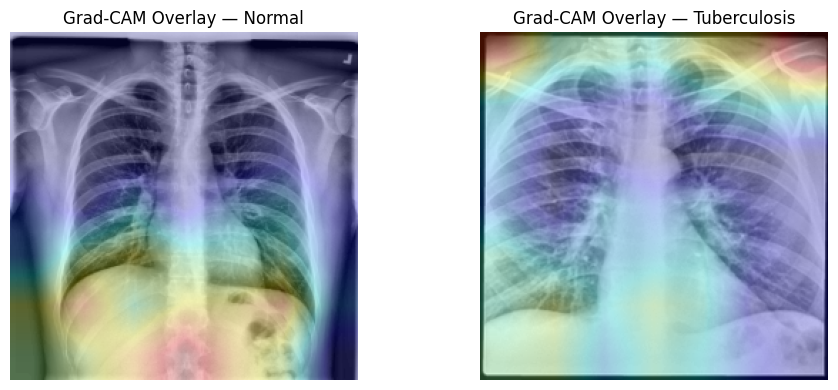

In [2]:
import cv2
RESULTS_DIR = PROJECT_ROOT / "data" / "notebooks" / "results" / "gradcam"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def overlay_cam_on_image(image_path, cam, alpha=0.25):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    h, w = img.shape

    cam_resized = cv2.resize(cam, (w, h), interpolation=cv2.INTER_LINEAR)

    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    heatmap = np.uint8(255 * cam_resized)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = heatmap.astype(np.float32) / 255.0

    img_rgb = np.stack([img, img, img], axis=-1)

    overlay = (1 - alpha) * img_rgb + alpha * heatmap
    overlay = np.clip(overlay, 0, 1)

    return overlay


overlay_normal = overlay_cam_on_image(normal_img_path, cam_normal)
overlay_tb = overlay_cam_on_image(tb_img_path, cam_tb)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(overlay_normal)
axes[0].set_title("Grad-CAM Overlay — Normal")
axes[0].axis("off")

axes[1].imshow(overlay_tb)
axes[1].set_title("Grad-CAM Overlay — Tuberculosis")
axes[1].axis("off")

plt.tight_layout()
plt.imsave(RESULTS_DIR / "normal_overlay.png", overlay_normal)
plt.imsave(RESULTS_DIR / "tuberculosis_overlay.png", overlay_tb)

fig.savefig(
    RESULTS_DIR / "overlay_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
